# Regresión Lineal: Guía de Estudio

En esta guía vamos a explorar los **conceptos fundamentales de la regresión lineal**. Desde cómo generamos datos, pasando por el cálculo de métricas de evaluación, hasta la visualización de resultados. 

Por lo tanto, verás cómo un modelo lineal se comporta bajo diferentes escenarios: datos ideales, datos con ruido y datos con outliers. Esto te ayudará a entender qué tan sensible es nuestro modelo a las imperfecciones del mundo real.

In [ ]:
# Importar las librerías principales
import numpy as np                                          # Operaciones numéricas
import matplotlib.pyplot as plt                             # Visualización
import seaborn as sns                                       # Estilos mejorados para gráficos
import pandas as pd                                         # Tablas de datos (DataFrames)
from sklearn.linear_model import LinearRegression           # Modelo de regresión lineal
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  # Métricas de evaluación

## 1. Primero, importamos las librerías necesarias

Para trabajar con regresión lineal necesitamos varias herramientas:

- **NumPy**: Para operaciones numéricas y generación de datos aleatorios
- **Matplotlib**: Para crear visualizaciones
- **Seaborn**: Para gráficos más bonitos y con estilos mejorados
- **Scikit-learn**: La librería estrella que contiene el modelo de regresión lineal y las métricas
- **Pandas**: Para organizar nuestros resultados en tablas (DataFrames)

In [ ]:
# Aplicar tema oscuro
plt.style.use('dark_background')
sns.set_theme(style="darkgrid")

# Personalizar colores y estilos
plt.rcParams['figure.facecolor'] = '#1a1a1a'
plt.rcParams['axes.facecolor'] = '#2b2b2b'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['text.color'] = '#ffffff'
plt.rcParams['axes.labelcolor'] = '#ffffff'
plt.rcParams['xtick.color'] = '#ffffff'
plt.rcParams['ytick.color'] = '#ffffff'

## 2. Configuramos el estilo visual

Aunque el código es lo importante, un buen estilo visual hace que nuestros gráficos sean más legibles. Por eso vamos a configurar un tema oscuro que es más cómodo para los ojos cuando estudias. De esta forma, los gráficos tendrán una apariencia profesional y consistente.

In [ ]:
# Fijar la semilla para reproducibilidad
np.random.seed(42)

# Crear datos X (variable independiente) de 0 a 50 con 200 puntos
X = np.linspace(0, 50, 200)

# Crear datos Y que siguen la relación lineal: y = 2x + 5
y = 2 * X + 5

## 3. Generamos datos para nuestro modelo

Aquí creamos datos artificiales que siguen una relación lineal: **y = 2x + 5**

La idea es usar datos que conocemos perfectamente, así podemos ver exactamente qué tan bien nuestro modelo puede aproximarse a esa relación. Usamos `np.random.seed(42)` para asegurar que los números aleatorios sean siempre los mismos (reproducibilidad).

In [ ]:
# Caso 1: Datos con ruido pequeño (datos realistas)
y_pred = y + np.random.normal(0, 2.5, 200)

# Caso 2: Datos con ruido grande (mediciones muy imprecisas)
y_pred_noise = y + np.random.normal(0, 10, 200)

# Caso 3: Datos con outliers (valores anómalos)
y_pred_outliers = y_pred.copy()
y_pred_outliers[25] += 40    # Error grande en posición 25
y_pred_outliers[50] -= 40    # Error grande en posición 50
y_pred_outliers[100] += 40   # Error grande en posición 100
y_pred_outliers[150] += 40   # Error grande en posición 150

## 4. Simulamos diferentes escenarios del mundo real

En la práctica, los datos nunca son perfectos. Por eso creamos tres versiones de nuestros datos:

1. **Con ruido pequeño** (`y_pred_noise`): Simula mediciones ligeramente imprecisas (desviación estándar de 2.5)
2. **Con ruido grande** (`y_pred_noise`): Simula mediciones muy imprecisas (desviación estándar de 10)
3. **Con outliers**: Simula valores anómalos o errores graves en ciertos puntos

De esta manera, podremos ver cómo el modelo se comporta en diferentes condiciones. Esto es crucial para entender la robustez de nuestro modelo.

In [ ]:
# Ejemplo: Calculemos estas métricas para nuestro primer caso (ruido pequeño)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

## 5. Entender las métricas de evaluación

Para saber **qué tan bien** funciona nuestro modelo, necesitamos medir el error. Existen varias formas de hacerlo:

- **MSE (Error Cuadrático Medio)**: Promedio de los errores al cuadrado. Penaliza mucho los errores grandes.
- **RMSE (Raíz del Error Cuadrático Medio)**: Es la raíz cuadrada del MSE. Está en las mismas unidades que y.
- **MAE (Error Absoluto Medio)**: Promedio del valor absoluto de los errores. Más simple de interpretar.
- **R² (Coeficiente de Determinación)**: Indica qué porcentaje de la varianza en los datos es explicada por el modelo. Rango: 0 a 1 (mejor si es más cercano a 1).

Por lo tanto, usaremos estas métricas para comparar qué tan bien se comporta nuestro modelo en cada escenario.

In [ ]:
def model_evaluate(name: str, true, pred):
    """
    Evalúa un modelo calculando sus métricas principales.
    
    Parámetros:
    - name: Nombre del modelo (string)
    - true: Valores reales (array)
    - pred: Predicciones del modelo (array)
    
    Retorna:
    - Dictionary con las métricas calculadas
    """
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)

    return {
        'model': name, 
        'mse': mse, 
        'rmse': rmse, 
        'mae': mae, 
        'r2': r2
    }

## 6. Crear una función reutilizable

En lugar de calcular las métricas una por una, vamos a crear una función que lo haga automáticamente. De esta forma, podemos evaluar fácilmente múltiples modelos sin repetir código. Esto es una buena práctica en programación: **DRY** (Don't Repeat Yourself).

In [ ]:
# Evaluamos el modelo en todos los escenarios
resultados = [
    model_evaluate('Ideal', y, y_pred),
    model_evaluate('Con Ruido', y, y_pred_noise),
    model_evaluate('Con Outliers', y, y_pred_outliers)
]

# Convertir a DataFrame para una mejor visualización
data = pd.DataFrame(resultados).set_index('model')
data

,mse,rmse,mae,r2
model,,,,
Ideal,6.190723,2.488116,1.992733,0.992645
With Noise,103.441458,10.170617,8.084512,0.877105
With Outliers,40.634801,6.374543,2.792733,0.951723


## 7. Evaluamos todos los escenarios

Ahora aplicamos nuestra función a los tres casos diferentes. Así podemos comparar cómo se desempeña el modelo en cada situación. Los datos se organizarán en una tabla (DataFrame) para que sea más fácil leerlos y compararlos.

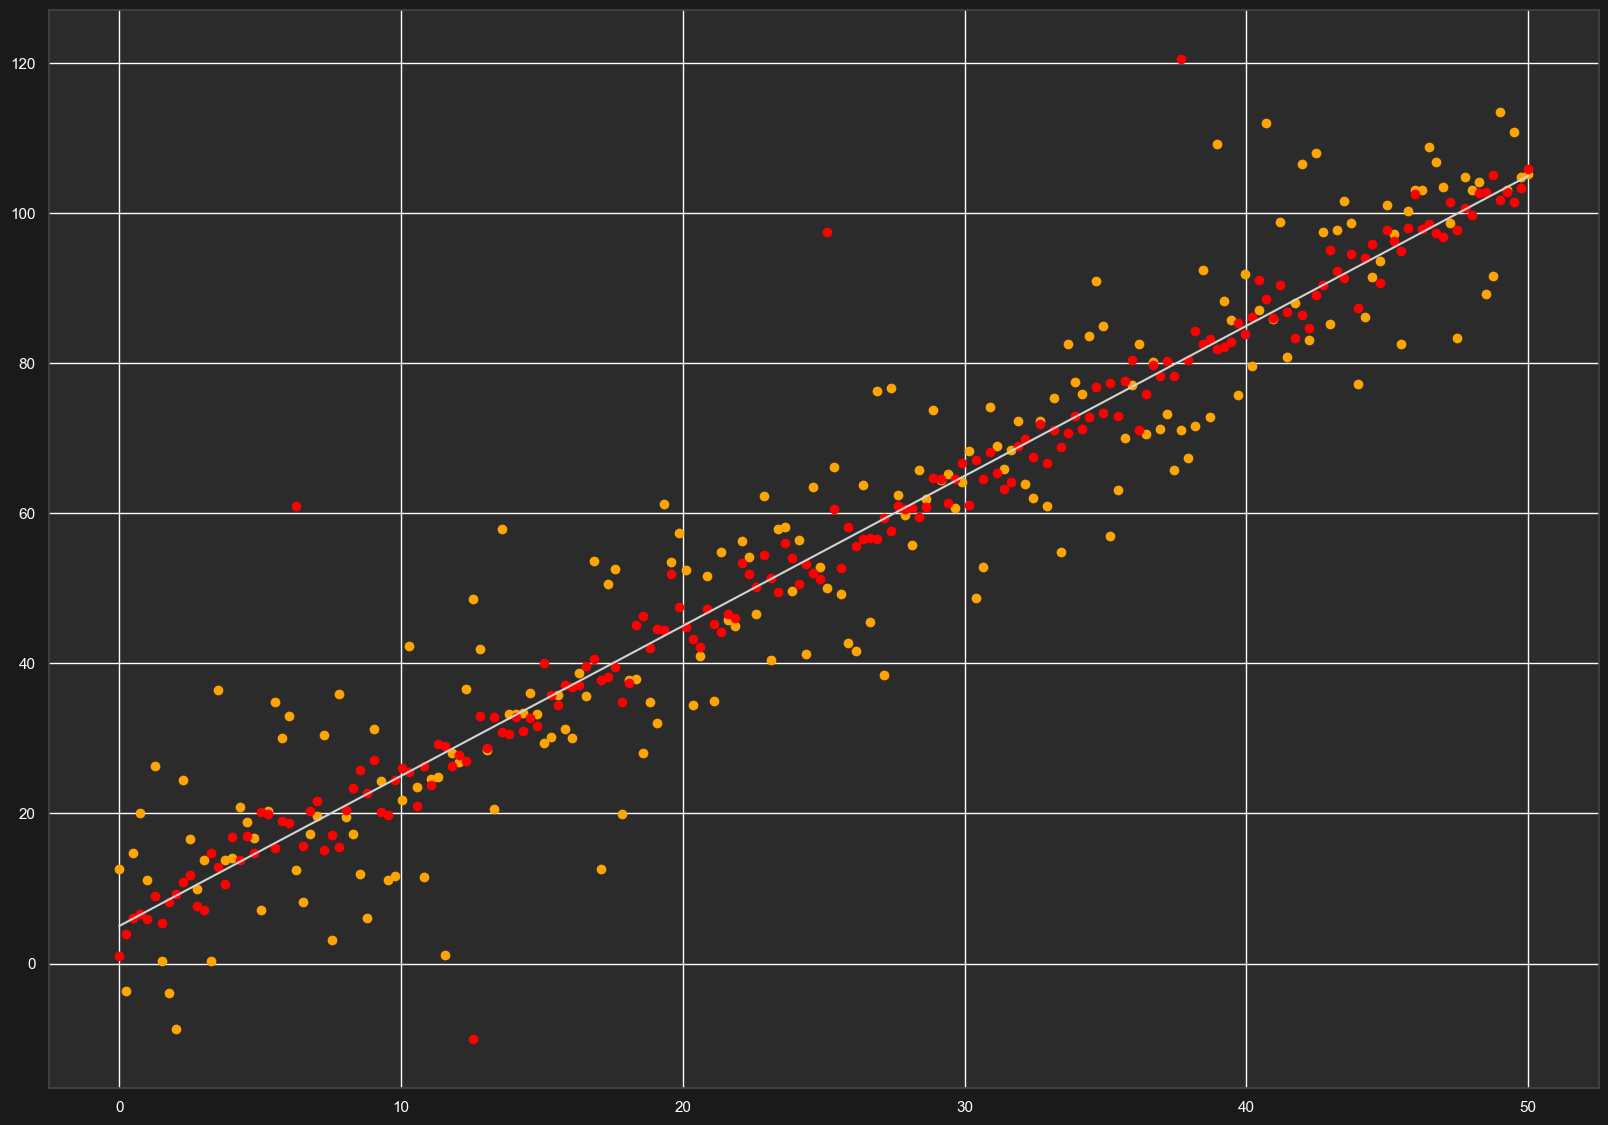

In [ ]:
figure = plt.figure(figsize=(15, 8))

ax1 = figure.add_subplot()
ax1.plot(X, y, color='lightgray', linewidth=2, label='Datos Reales (Ideales)')
ax1.scatter(X, y_pred, color='cyan', alpha=0.5, s=30, label='Con Ruido Pequeño')
ax1.scatter(X, y_pred_noise, color='orange', alpha=0.5, s=30, label='Con Ruido Grande')
ax1.scatter(X, y_pred_outliers, color='red', alpha=0.7, s=50, label='Con Outliers')

ax1.set_xlabel('X (Variable Independiente)', fontsize=12)
ax1.set_ylabel('Y (Variable Dependiente)', fontsize=12)
ax1.set_title('Comparación de Datos Reales vs Predicciones', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Visualizamos la relación entre datos reales y predicciones

Este gráfico muestra claramente cómo los datos se dispersan alrededor de la línea ideal. 

- La **línea gris** representa los datos reales perfectos (sin error)
- Los **puntos naranja** muestran cómo se vería con ruido moderado
- Los **puntos rojos** muestran el caso con outliers

Así puedes ver visualmente cómo los errores afectan la distribución de nuestros datos.

<StemContainer object of 3 artists>

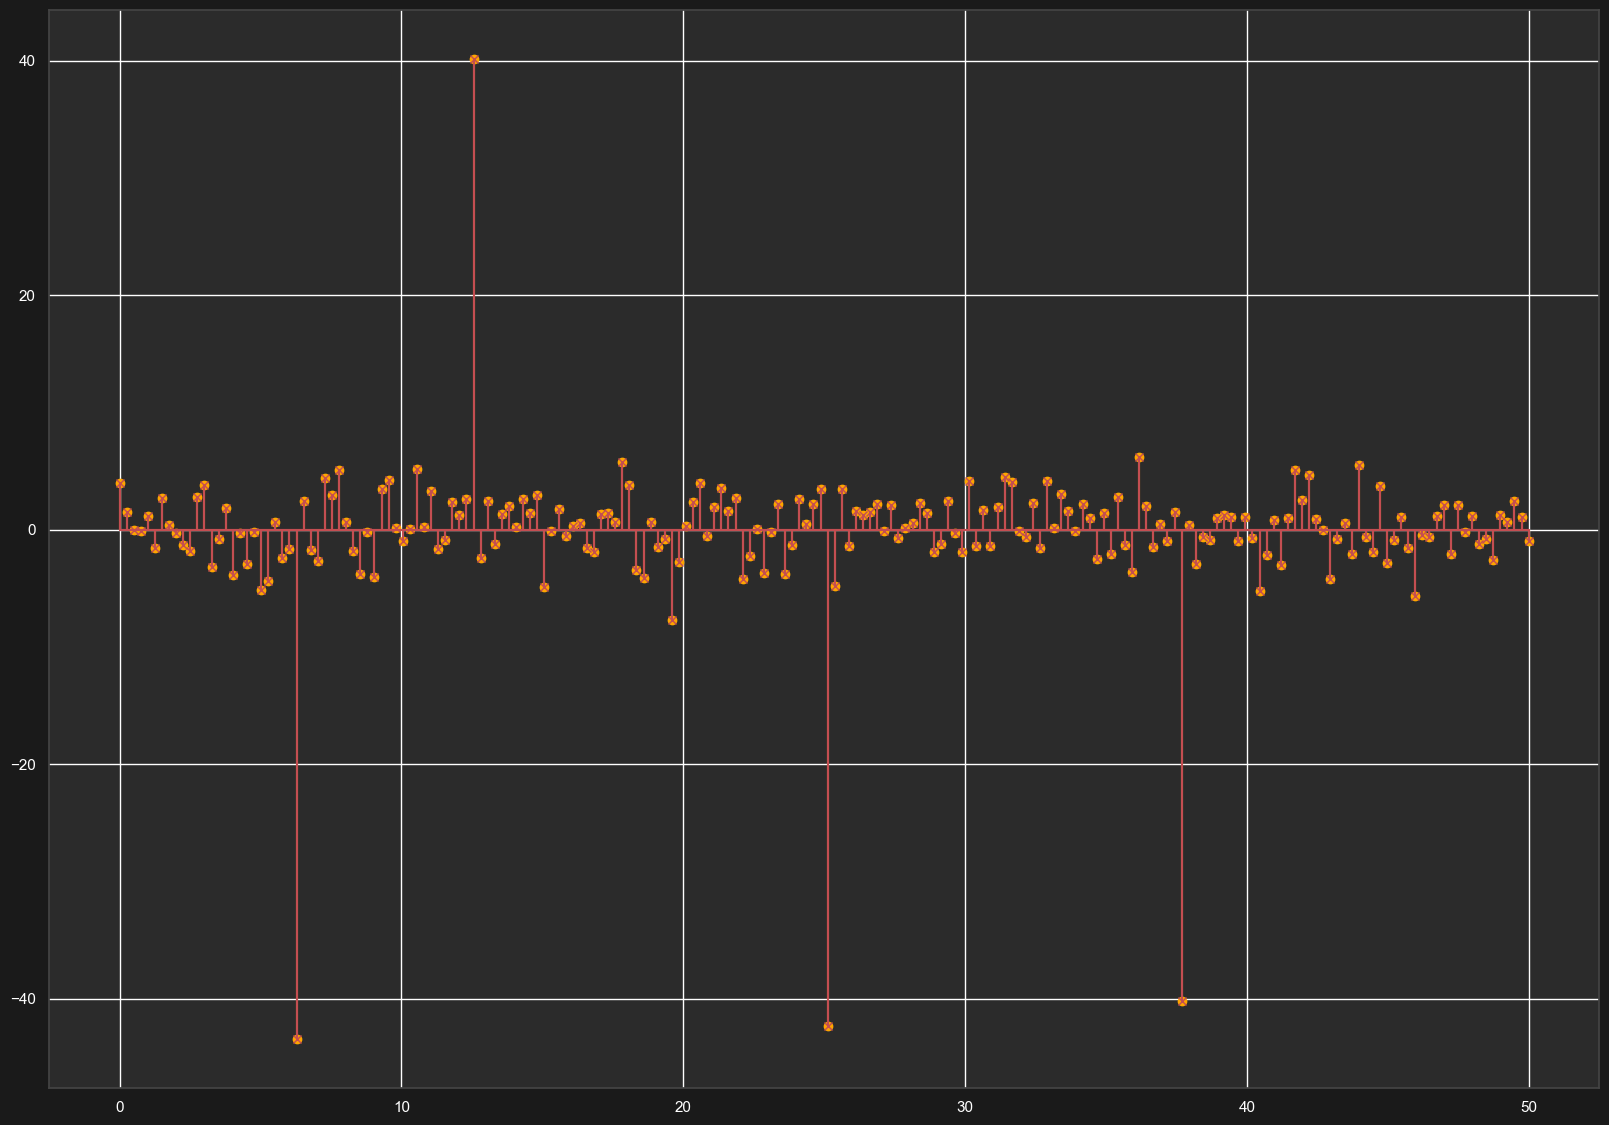

In [ ]:
figure = plt.figure(figsize=(15, 8))

ax2 = figure.add_subplot()

# Gráfico de residuos del caso con ruido
ax2.stem(X, y - y_pred, linefmt='cyan', markerfmt='co', label='Residuos (Ruido Pequeño)')

# Gráfico de residuos del caso con outliers (es más evidente)
ax2.stem(X, y - y_pred_outliers, linefmt='r-', markerfmt='rx', label='Residuos (Outliers)')

ax2.axhline(y=0, color='white', linestyle='--', alpha=0.5, linewidth=1)
ax2.set_xlabel('X', fontsize=12)
ax2.set_ylabel('Residuo (Error)', fontsize=12)
ax2.set_title('Análisis de Residuos: Donde el Modelo se Equivoca', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Analizamos los residuos (errores)

Los **residuos** son la diferencia entre lo que el modelo predijo y lo que realmente sucedió: `error = valor_real - predicción`

Este gráfico de residuos es importante porque:
- Si todos los residuos estuvieran alrededor de cero, sería perfecto
- Los residuos grandes en puntos específicos indican que el modelo tiene problemas en esas zonas
- Los outliers crean "picos" grandes en el gráfico, lo que muestra claramente dónde están los problemas

Así podemos diagnosticar visualmente dónde el modelo se equivoca más.

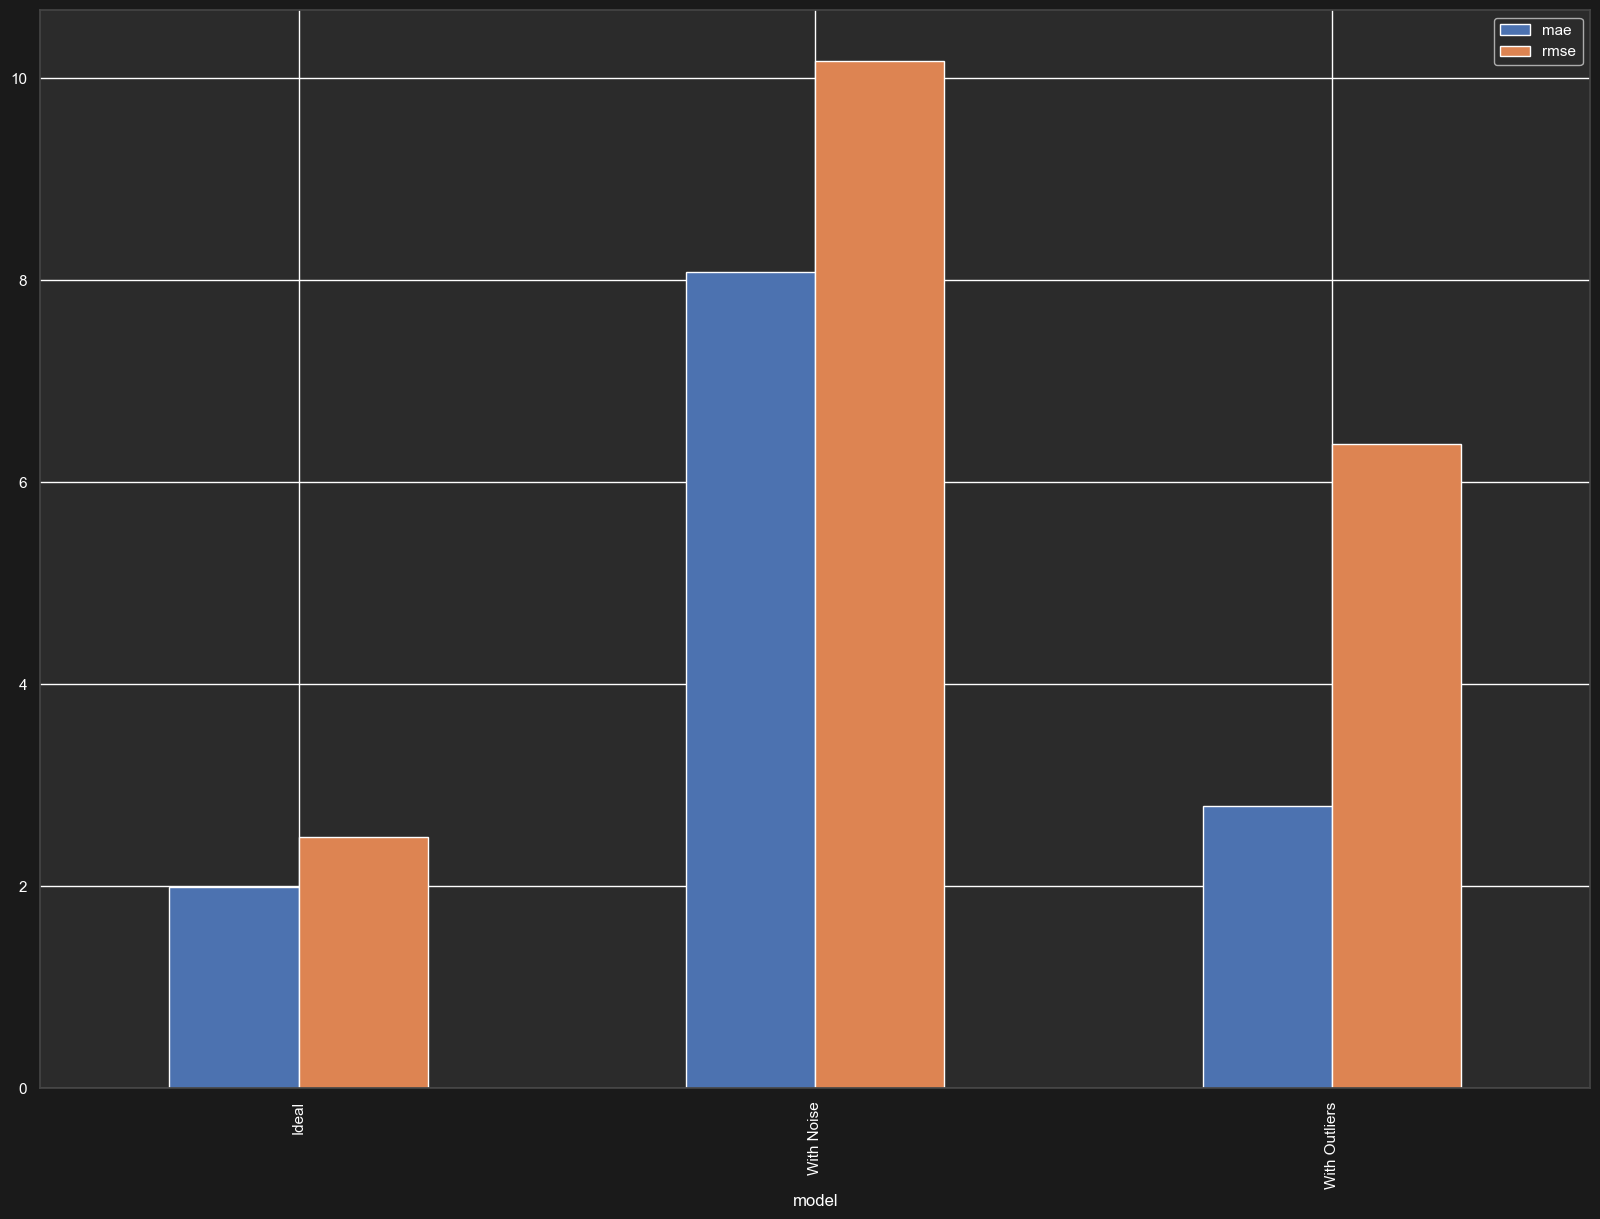

In [ ]:
figure = plt.figure(figsize=(15, 8))

ax3 = figure.add_subplot()

# Crear gráfico de barras para comparar MAE y RMSE
data[['mae', 'rmse']].plot(
    kind='bar', 
    ax=ax3,
    color=['#00ffff', '#ff00ff'],
    alpha=0.8,
    width=0.7
)

ax3.set_xlabel('Escenario', fontsize=12)
ax3.set_ylabel('Error', fontsize=12)
ax3.set_title('Comparación de Métricas de Error entre Escenarios', fontsize=14, fontweight='bold')
ax3.legend(['MAE (Error Absoluto Medio)', 'RMSE (Raíz del Error Cuadrático)'], fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Conclusiones clave 📚

¿Qué hemos aprendido en esta guía?

1. **La regresión lineal es simple pero poderosa**: Puede encontrar relaciones lineales en los datos con un modelo muy interpretable.

2. **Los datos reales son messy**: En la práctica siempre hay ruido, outliers y errores. Por eso debemos evaluar nuestro modelo en diferentes escenarios.

3. **Necesitamos métricas para medir el desempeño**: No podemos confiar solo en lo que "se ve bien". Los números (MSE, RMSE, MAE, R²) nos dicen la verdad sobre qué tan bueno es nuestro modelo.

4. **Los outliers rompen todo**: Un solo valor extremo puede aumentar enormemente nuestras métricas de error. Por eso es importante limpiar datos antes de entrenar.

5. **Visualización es fundamental**: Un gráfico de residuos nos muestra rápidamente dónde el modelo falla, mucho mejor que solo mirar números.

---

**Próximos pasos:** Ahora que entiendes cómo evaluar un modelo, puedes experimentar con:
- Diferentes técnicas de limpieza de datos (remover outliers)
- Modelos más complejos (polinomial, ridge regression)
- Validación cruzada para evaluar mejor el desempeño

## 10. Comparamos visualmente las métricas de error

Ahora vemos gráficamente cómo cambian el **MAE** (Error Absoluto Medio) y **RMSE** (Raíz del Error Cuadrático Medio) entre los tres escenarios.

**Interpretación:**
- Un gráfico más alto = mayor error = peor desempeño del modelo
- Esperas que "Con Ruido" sea intermedio
- "Con Outliers" debería ser el más alto porque los outliers son errores muy grandes

Este análisis visual complementa la tabla que vimos antes y facilita la comparación rápida.